<a href="https://colab.research.google.com/github/akashakash19/Food-delivery-time-prediction/blob/main/Food_delivery_time_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Food delivery time prediction work flow**

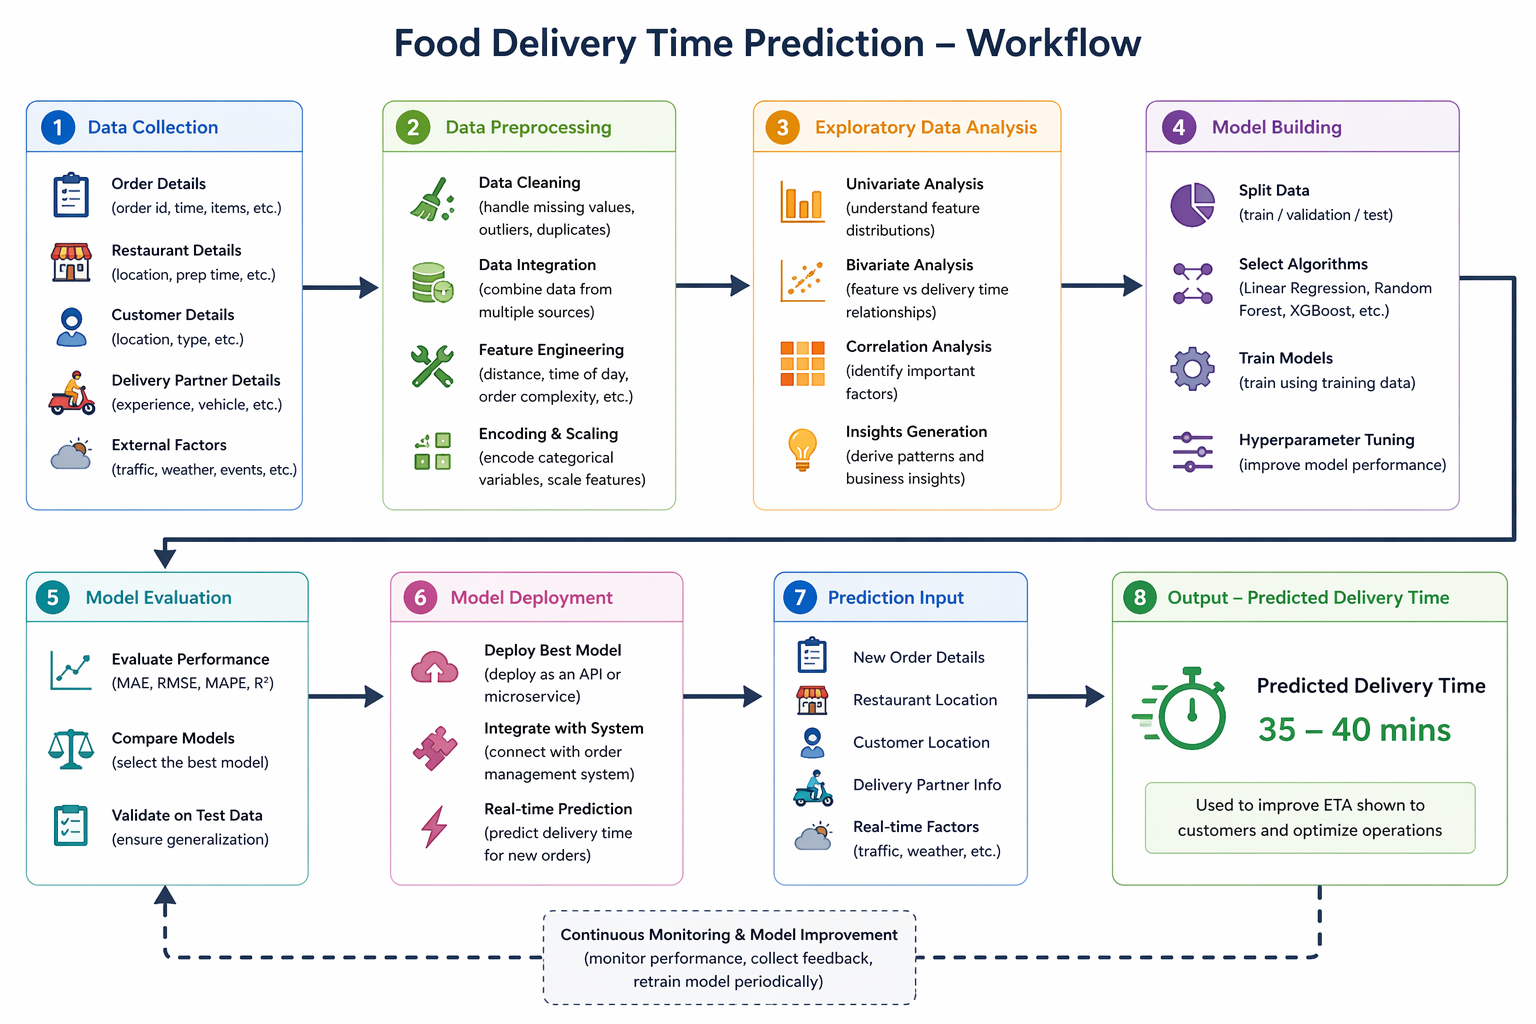

**Import dependencies**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats   #Used for statistical analysis
import statistics             #Used for basic statistics
from geopy.distance import geodesic       #Used to calculate distance between two locations (lat, lon)

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  #Splits data into multiple parts (folds),Finds best parameters automatically
from sklearn.preprocessing import LabelEncoder, StandardScaler  #convet text to numbers, Normalize number same range ( 0 to 1)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [7]:
food_est = pd.read_csv('/content/train (1).csv')
food_est.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [8]:
food_est.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [9]:
print("Dataset shape : ", food_est.shape)

Dataset shape :  (45593, 20)


here we have 45593 rows and 20 columns

In [10]:
food_est.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [11]:
#Check statistical values for fields with numerical datatype
food_est.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


In [12]:
#Check statistical values for fields with other than numerical datatype
food_est.describe(exclude=np.number).T    #“Ignore numeric columns, show only categorical (text) columns”

,count,unique,top,freq
ID,45593,45593,0x5fb2,1
Delivery_person_ID,45593,1320,PUNERES01DEL01,67
Delivery_person_Age,45593,23,35,2262
Delivery_person_Ratings,45593,29,4.8,7148
Order_Date,45593,44,15-03-2022,1192
Time_Orderd,45593,177,NaN,1731
Time_Order_picked,45593,193,21:30:00,496
Weatherconditions,45593,7,conditions Fog,7654
Road_traffic_density,45593,5,Low,15477
Type_of_order,45593,4,Snack,11533


In [13]:
#Explore each columns
for col in food_est.columns:
  print(col)
  print(food_est[col].value_counts())
  print('--------------------------------')

ID
ID
0x5fb2     1
0x4607     1
0xb379     1
0x5d6d     1
0x7a6a     1
          ..
0xdb64     1
0xc8b6     1
0x2784     1
0xd987     1
0xcdcd     1
Name: count, Length: 45593, dtype: int64
--------------------------------
Delivery_person_ID
Delivery_person_ID
PUNERES01DEL01       67
JAPRES11DEL02        67
VADRES08DEL02        66
RANCHIRES02DEL01     66
HYDRES04DEL02        66
                     ..
BHPRES15DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64
--------------------------------
Delivery_person_Age
Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64
--------------------------------
Deli

#**Data cleaning and Analyzing**

In [14]:
#update column name
def update_column_name(food):
  #Renaming weathercondition column
  food.rename(columns = {'Weatherconditions':'Weather_conditions'},inplace=True)
update_column_name(food_est)
print(food_est.columns)


Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')


In [15]:
#Extract relevant values from column
def extract_column_value(food):
    #Extract time and convert to int
    food["Time_taken(min)"]=food["Time_taken(min)"].apply(lambda x: int(x.split(' ')[1].strip()))
    #Extract Weather conditions
    food["Weather_conditions"]=food["Weather_conditions"].apply(lambda x: x.split(' ')[1].strip())
    #Extract city code from Delivery person ID
    food["City_code"]=food["Delivery_person_ID"].str.split("RES", expand=True)[0]
extract_column_value(food_est)
food_est[["Time_taken(min)", "Weather_conditions", "City_code"]].head()

,Time_taken(min),Weather_conditions,City_code
0,24,Sunny,INDO
1,33,Stormy,BANG
2,26,Sandstorms,BANG
3,21,Sunny,COIMB
4,30,Cloudy,CHEN


In [16]:
#Drop Columns which won't be use for building model
def drop_columns(food):
  food.drop(['ID','Delivery_person_ID'], axis = 1, inplace = True)
print("Before No. of columns: ", food_est.shape[1])
drop_columns(food_est)
print("After No. of colums: ", food_est.shape[1])

Before No. of columns:  21
After No. of colums:  19


In [17]:
#Check for Duplicate Values
if (len(food_est[food_est.duplicated()])>0):
    print("There are duplicate values present")
else:
    print("There is no duplicate values present")

There is no duplicate values present


In [18]:
def update_datatype(food):
  food['Delivery_person_Age'] = food['Delivery_person_Age'].astype("float64")
  food['Delivery_person_Ratings'] = food['Delivery_person_Ratings'].astype("float64")
  food['multiple_deliveries'] = food['multiple_deliveries'].astype("float64")
  food['Order_Date'] = pd.to_datetime(food['Order_Date'], format="%d-%m-%Y")

update_datatype(food_est)

In [19]:
#Convert String 'NaN' to np.nan
def convert_nan(food):
    food.replace("NaN", float(np.nan), regex=True, inplace=True)

convert_nan(food_est)

In [20]:
food_est.isnull().sum().sort_values(ascending=False)

,0
Delivery_person_Ratings,1908
Delivery_person_Age,1854
Time_Orderd,1731
City,1200
multiple_deliveries,993
Weather_conditions,616
Road_traffic_density,601
Festival,228
Restaurant_latitude,0
Order_Date,0


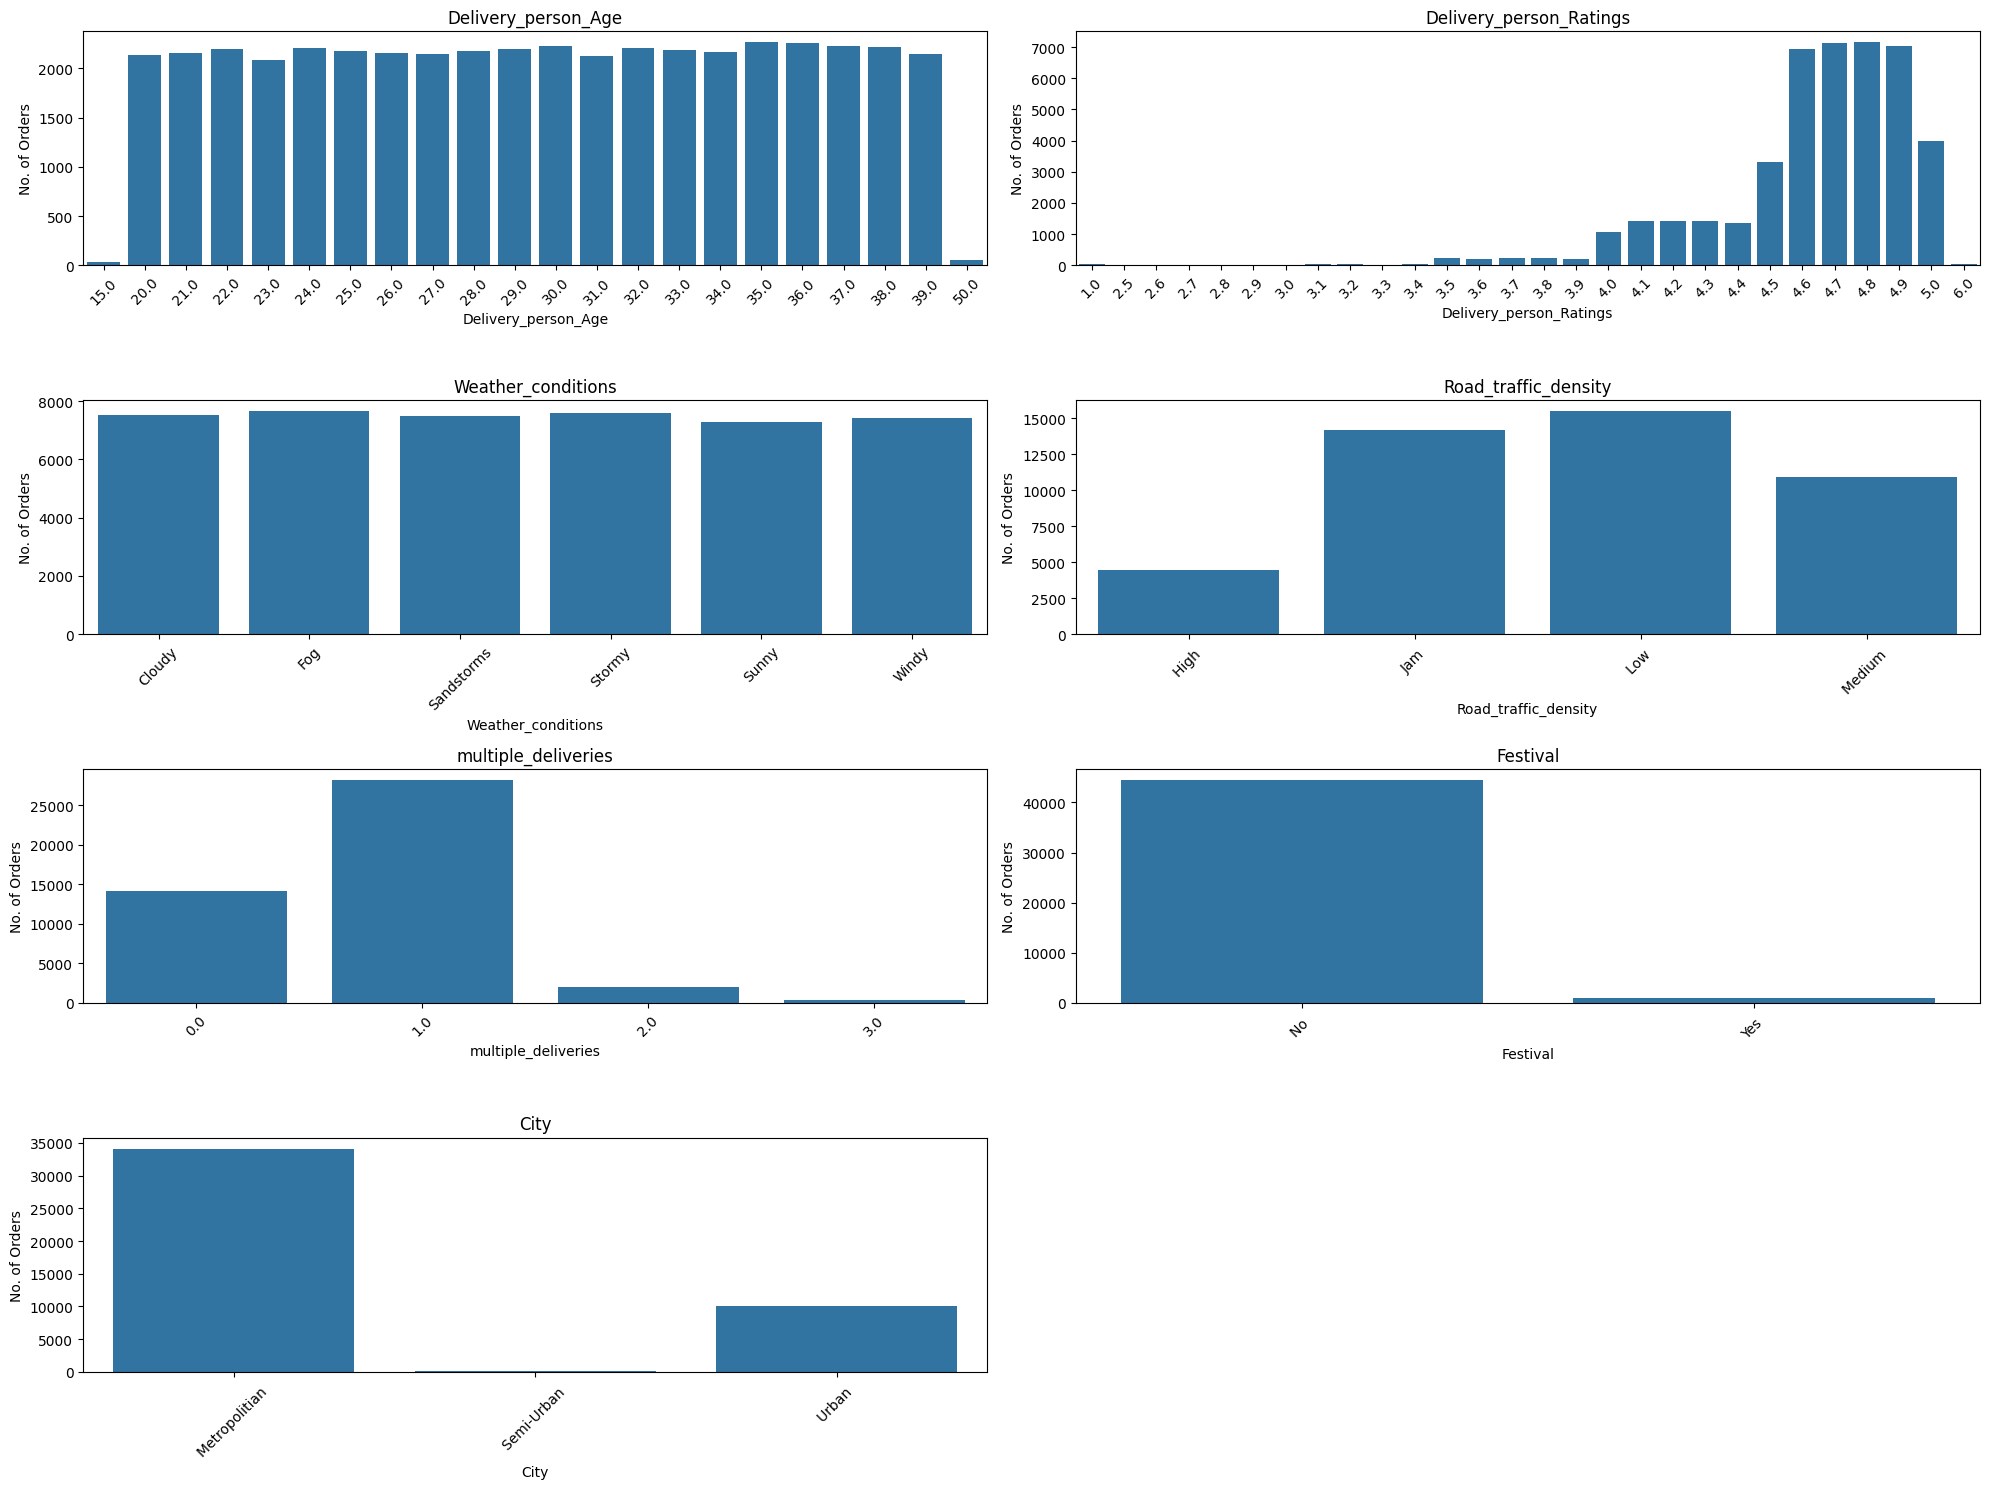

In [21]:
#Let's explore columns that have null values
cols = ['Delivery_person_Age','Delivery_person_Ratings','Weather_conditions','Road_traffic_density','multiple_deliveries','Festival','City']
num_plots = len(cols)
num_rows = (num_plots // 2) + (num_plots % 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(20,15))

for i, column_name in enumerate(cols):
    row = i // 2
    col = i % 2

    ax = axes[row, col]
    sns.countplot(data=food_est, x=column_name, order=food_est[column_name].value_counts().sort_index().index, ax=ax)

    ax.set_xlabel(column_name)
    ax.set_ylabel('No. of Orders')
    ax.set_title(column_name)
    ax.tick_params(axis='x', rotation=45)

if num_plots % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()

In [22]:
# Handle null values
def handle_null_values(food):

    food["Delivery_person_Age"] = food["Delivery_person_Age"].fillna(np.random.choice(food["Delivery_person_Age"]))
    food["Weather_conditions"] = food["Weather_conditions"].fillna(np.random.choice(food["Weather_conditions"]))
    food["City"] = food["City"].fillna(food["City"].mode()[0])
    food["Festival"] = food["Festival"].fillna(food["Festival"].mode()[0])
    food["multiple_deliveries"] = food["multiple_deliveries"].fillna(food["multiple_deliveries"].mode()[0])
    food["Road_traffic_density"] = food["Road_traffic_density"].fillna(food["Road_traffic_density"].mode()[0])
    food["Delivery_person_Ratings"] = food["Delivery_person_Ratings"].fillna(food["Delivery_person_Ratings"].median())

# Apply the function to df_train
handle_null_values(food_est)

# Check for remaining null values
food_est.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731
Time_Order_picked,0
Weather_conditions,0


#**Feature Engineering**

In [23]:
def extract_date_features(data):
    data["day"] = data.Order_Date.dt.day
    data["month"] = data.Order_Date.dt.month
    data["quarter"] = data.Order_Date.dt.quarter
    data["year"] = data.Order_Date.dt.year
    data['day_of_week'] = data.Order_Date.dt.day_of_week.astype(int)
    data["is_month_start"] = data.Order_Date.dt.is_month_start.astype(int)
    data["is_month_end"] = data.Order_Date.dt.is_month_end.astype(int)
    data["is_quarter_start"] = data.Order_Date.dt.is_quarter_start.astype(int)
    data["is_quarter_end"] = data.Order_Date.dt.is_quarter_end.astype(int)
    data["is_year_start"] = data.Order_Date.dt.is_year_start.astype(int)
    data["is_year_end"] = data.Order_Date.dt.is_year_end.astype(int)
    data['is_weekend'] = np.where(data['day_of_week'].isin([5,6]),1,0)

extract_date_features(food_est)
food_est.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,...,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,...,1,2022,5,0,0,0,0,0,0,1
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,...,1,2022,4,0,0,0,0,0,0,0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,...,1,2022,5,0,0,0,0,0,0,1
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,...,2,2022,1,0,0,0,0,0,0,0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,...,1,2022,5,0,0,0,0,0,0,1


In [24]:
def calculate_time_diff(df):
    # Convert the time columns to timedelta
    df['Time_Orderd'] = pd.to_timedelta(df['Time_Orderd'])
    df['Time_Order_picked'] = pd.to_timedelta(df['Time_Order_picked'])

    # Correctly format the picked time, handling cases where picked time is on the next day
    df['Time_Order_picked_formatted'] = df['Order_Date'] + df['Time_Order_picked']
    mask = df['Time_Order_picked'] < df['Time_Orderd']
    df.loc[mask, 'Time_Order_picked_formatted'] += pd.DateOffset(days=1)

    # Format the ordered time
    df['Time_Ordered_formatted'] = df['Order_Date'] + df['Time_Orderd']

    # Calculate the order preparation time in minutes
    df['order_prepare_time'] = (df['Time_Order_picked_formatted'] - df['Time_Ordered_formatted']).dt.total_seconds() / 60

    # Handle null values by assigning the result of fillna() to the column explicitly
    df['order_prepare_time'] = df['order_prepare_time'].fillna(df['order_prepare_time'].median())

    # Drop all the time & date related columns
    df.drop(['Time_Orderd', 'Time_Order_picked', 'Time_Ordered_formatted', 'Time_Order_picked_formatted', 'Order_Date'], axis=1, inplace=True)

# Assuming df_train is your DataFrame
calculate_time_diff(food_est)
food_est.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,...,2022,5,0,0,0,0,0,0,1,15.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,...,2022,4,0,0,0,0,0,0,0,5.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,...,2022,5,0,0,0,0,0,0,1,15.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,...,2022,1,0,0,0,0,0,0,0,10.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,...,2022,5,0,0,0,0,0,0,1,15.0


In [25]:
# Calculate distance between restaurant location & delivery location
from geopy.distance import geodesic    #Using geopy to calculate real-world distance

def calculate_distance(food):
    # Initialize the distance column with zeros
    food["distance"] = np.zeros(len(food))

    # Get the restaurant and delivery coordinates as numpy arrays
    restaurant_coordinates = food[['Restaurant_latitude', 'Restaurant_longitude']].to_numpy()
    delivery_location_coordinates = food[['Delivery_location_latitude', 'Delivery_location_longitude']].to_numpy()

    # Calculate geodesic distance between restaurant and delivery locations
    food["distance"] = np.array([geodesic(restaurant, delivery).kilometers for restaurant, delivery in zip(restaurant_coordinates, delivery_location_coordinates)])

# Apply the function to df_train
calculate_distance(food_est)
food_est.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time,distance
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,...,5,0,0,0,0,0,0,1,15.0,3.020737
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,...,4,0,0,0,0,0,0,0,5.0,20.143737
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,...,5,0,0,0,0,0,0,1,15.0,1.549693
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,...,1,0,0,0,0,0,0,0,10.0,7.774497
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,...,5,0,0,0,0,0,0,1,15.0,6.197898


#**Data preprocessing**

**Label_Encoding**

In [26]:
from sklearn.preprocessing import LabelEncoder

def label_encoding(food):
  categorical_cols = food.select_dtypes(include='object').columns
  label_encoder = LabelEncoder()
  food[categorical_cols] = food[categorical_cols].apply(lambda col: label_encoder.fit_transform(col))

label_encoding(food_est)
food_est.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time,distance
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,4,0,2,3,...,5,0,0,0,0,0,0,1,15.0,3.020737
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,3,1,2,3,...,4,0,0,0,0,0,0,0,5.0,20.143737
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2,2,0,1,...,5,0,0,0,0,0,0,1,15.0,1.549693
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,4,3,0,0,...,1,0,0,0,0,0,0,0,10.0,7.774497
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,0,0,1,3,...,5,0,0,0,0,0,0,1,15.0,6.197898


In [27]:
#Print all column names to check for any hidden characters or formatting issues
print(food_est.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'City_code', 'day', 'month', 'quarter', 'year', 'day_of_week', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 'is_weekend', 'order_prepare_time', 'distance']


**Train_Test_Split**

In [28]:
# removes extra spaces
food_est.columns = food_est.columns.str.strip()

# select only needed features
# Now try dropping the column again
X = food_est.drop('Time_taken(min)', axis=1)  # Features
Y = food_est['Time_taken(min)']  # Target variable

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=32
)

print(X.shape, X_train.shape, X_test.shape)



(45593, 29) (36474, 29) (9119, 29)


**Standardization**

In [29]:
# Create a StandardScaler object
scaler=StandardScaler()
# Fit the scaler on the training data
scaler.fit(X_train)

# Perform standardization on the training data
X_train=scaler.transform(X_train)

# Perform standardization on the testing data
X_test=scaler.transform(X_test)

#**Model Building**

1.Employ cross-validation & hyper parameter tuning to determine the optimal regression model.                          
2.Construct the food delivery prediction model using the identified best model.                   
3.Evaluate the model's performance on the testing data to assess its accuracy and reliability.

In [ ]:
#Find best model
models = [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    xgb.XGBRegressor(),
]

param_grid= [
    {},
    {"max_depth":[3,5,7]},
    {"n_estimators":[100,200,300]},
    {"n_estimators":[20, 25, 30], "max_depth":[5,7,9]}
]

for i, model in enumerate(models):
    grid_search=GridSearchCV(model, param_grid[i], cv=5, scoring="r2")
    grid_search.fit(X_train, Y_train)
    print(f"{model.__class__.__name__}")
    print("Best parameters: ", grid_search.best_params_)
    print("Best R2 score: ",grid_search.best_score_)
    print()

LinearRegression
Best parameters:  {}
Best R2 score:  0.22964832225547854

DecisionTreeRegressor
Best parameters:  {'max_depth': 5}
Best R2 score:  0.41414226296168016

RandomForestRegressor
Best parameters:  {'n_estimators': 300}
Best R2 score:  0.2554588991730612

XGBRegressor
Best parameters:  {'max_depth': 5, 'n_estimators': 20}
Best R2 score:  0.41726783514022825



**Model Building**

In [31]:
# Create a XGB regressor model
model=xgb.XGBRegressor(n_estimators=20, max_depth=9)

# Fit the model on the training data
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=None, num_parallel_tree=None, ...)

**Model Evolution**

In [32]:
# Make predictions on the test data
Y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R-squared (R2) Score:", round(r2,2))  #0 → bad, 1 - perfect

Mean Absolute Error (MAE): 3.13
Mean Squared Error (MSE): 15.42
Root Mean Squared Error (RMSE): 3.93
R-squared (R2) Score: 0.82


In [33]:
import pickle
# Define the file name
filename="model.pkl"

# Save the model using pickle
with open(filename,"wb") as file:
    pickle.dump(model,file)
print(f"Model saved to {filename}")

Model saved to model.pkl


In [34]:
# Define the filename

filename_scaler="scaler.pkl"

# Save the model using pickle
with open(filename_scaler, "wb") as file:
    pickle.dump(scaler, file)
print(f"Model saved to {filename_scaler}")

Model saved to scaler.pkl
